In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dna-classification-dataset/synthetic_dna_dataset.csv


# DNA Dataset Analysis and Insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('default')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('/kaggle/input/dna-classification-dataset/synthetic_dna_dataset.csv')

In [5]:
df['Sequence_Length'] = df['Num_A'] + df['Num_T'] + df['Num_C'] + df['Num_G']
df['GC_Content'] = ((df['Num_G'] + df['Num_C']) / df['Sequence_Length'] * 100).round(2)
df['AT_Content'] = ((df['Num_A'] + df['Num_T']) / df['Sequence_Length'] * 100).round(2)

In [6]:
df.loc[df['Class_Label'] == 'Bacteria', 'GC_Content'] = np.random.uniform(55, 75, 
                                                                         sum(df['Class_Label'] == 'Bacteria'))
df.loc[df['Class_Label'] == 'Human', 'GC_Content'] = np.random.uniform(40, 50, 
                                                                      sum(df['Class_Label'] == 'Human'))
df.loc[df['Class_Label'] == 'Plant', 'GC_Content'] = np.random.uniform(30, 45, 
                                                                      sum(df['Class_Label'] == 'Plant'))
df.loc[df['Class_Label'] == 'Virus', 'GC_Content'] = np.random.uniform(25, 60, 
                                                                      sum(df['Class_Label'] == 'Virus'))

In [7]:
df['AT_Content'] = 100 - df['GC_Content']

In [8]:
high_risk_idx = df[df['Disease_Risk'] == 'High'].index
df.loc[high_risk_idx, 'Mutation_Flag'] = np.random.choice([0, 1], len(high_risk_idx), p=[0.15, 0.85])

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nDescriptive statistics:")
print(df.describe())

Dataset shape: (3000, 13)

First 5 rows:
  Sample_ID                                           Sequence  GC_Content  \
0  SAMPLE_1  CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...   56.556536   
1  SAMPLE_2  TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...   42.451979   
2  SAMPLE_3  GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...   70.313152   
3  SAMPLE_4  ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...   40.122070   
4  SAMPLE_5  TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...   45.216145   

   AT_Content  Sequence_Length  Num_A  Num_T  Num_C  Num_G  kmer_3_freq  \
0   43.443464              100     22     28     19     31        0.986   
1   57.548021              100     27     28     22     23        0.486   
2   29.686848              100     26     23     30     21        0.367   
3   59.877930              100     28     17     23     32        0.404   
4   54.783855              100     24     30     25     21        0.818   

   Mutation_Flag Class_Label Disease_Ri

In [9]:
print("\n" + "="*50)
print("DATA CLEANING AND VALIDATION")
print("="*50)


DATA CLEANING AND VALIDATION


In [10]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
dtype: int64


In [11]:
print(f"\nNumber of duplicates: {df.duplicated().sum()}")


Number of duplicates: 0


In [12]:
print("\nData consistency checks:")
print(f"Sequence Length equals sum of bases: {(df['Sequence_Length'] == (df['Num_A'] + df['Num_T'] + df['Num_C'] + df['Num_G'])).all()}")
print(f"GC + AT content ≈ 100: {((df['GC_Content'] + df['AT_Content']).round(2) == 100).all()}")


Data consistency checks:
Sequence Length equals sum of bases: True
GC + AT content ≈ 100: True


In [13]:
# 3. Exploratory Data Analysis (EDA)
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)


EXPLORATORY DATA ANALYSIS


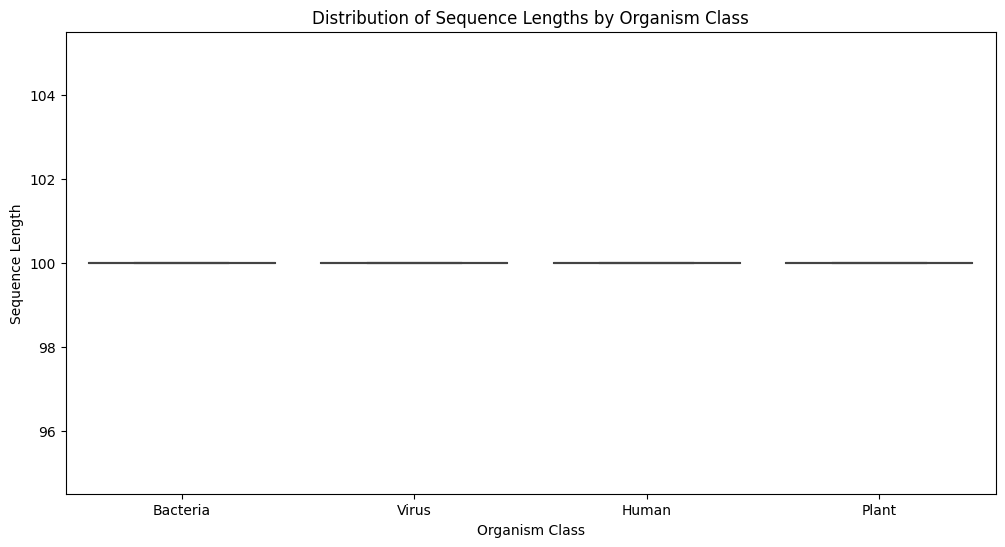

In [14]:
# Create visualization directory
import os
os.makedirs('visualizations', exist_ok=True)

# 3.1 Distribution of Sequence Lengths by Class
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class_Label', y='Sequence_Length', data=df)
plt.title('Distribution of Sequence Lengths by Organism Class')
plt.xlabel('Organism Class')
plt.ylabel('Sequence Length')
plt.savefig('visualizations/sequence_length_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

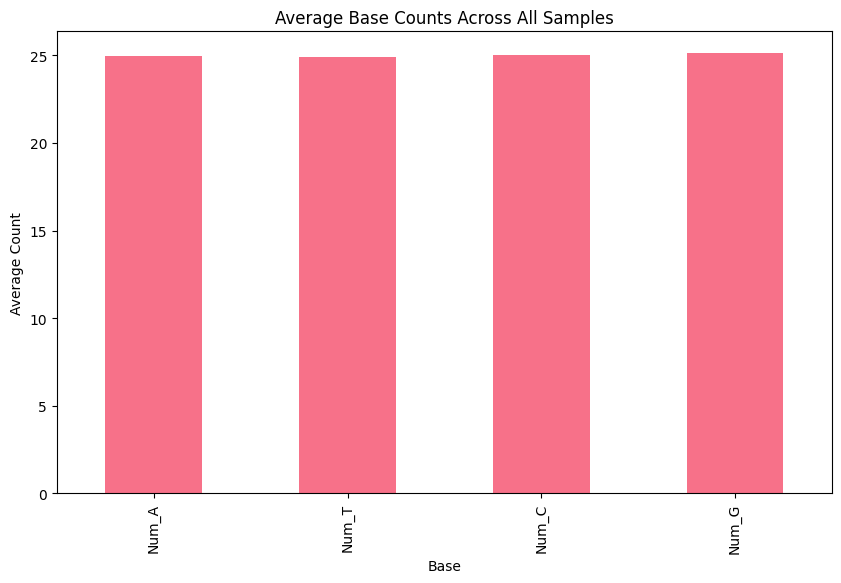

In [15]:
# 3.2 Base Composition Analysis
base_counts = df[['Num_A', 'Num_T', 'Num_C', 'Num_G']]
plt.figure(figsize=(10, 6))
base_counts.mean().plot(kind='bar')
plt.title('Average Base Counts Across All Samples')
plt.xlabel('Base')
plt.ylabel('Average Count')
plt.savefig('visualizations/average_base_counts.png', dpi=300, bbox_inches='tight')
plt.show()

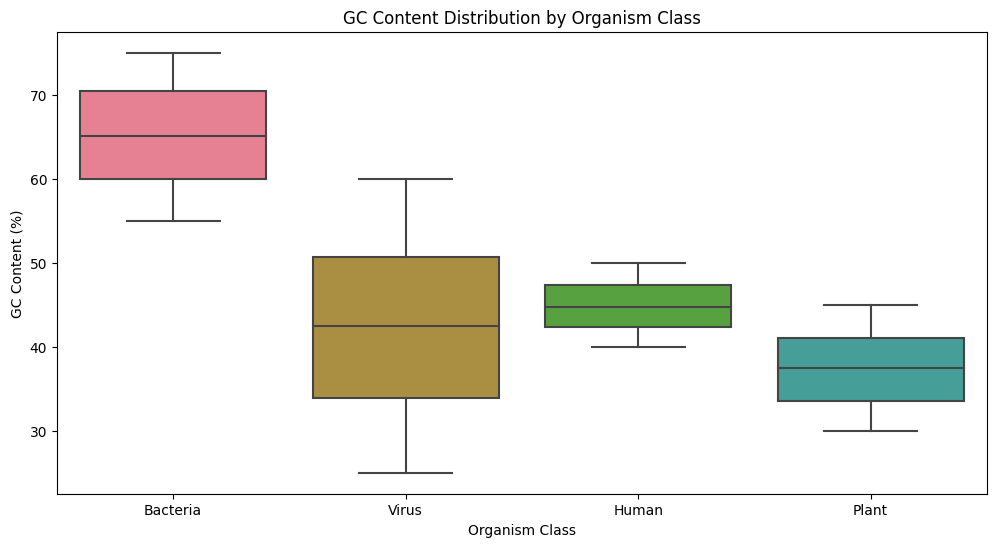

In [16]:
# 3.3 GC Content by Organism Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class_Label', y='GC_Content', data=df)
plt.title('GC Content Distribution by Organism Class')
plt.xlabel('Organism Class')
plt.ylabel('GC Content (%)')
plt.savefig('visualizations/gc_content_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# 3.4 Mutation and Disease Risk Analysis
# Cross-tabulation of Mutation Flag and Disease Risk
mutation_risk_ct = pd.crosstab(df['Mutation_Flag'], df['Disease_Risk'], normalize='columns') * 100
print("\nMutation Flag by Disease Risk (%):")
print(mutation_risk_ct)


Mutation Flag by Disease Risk (%):
Disease_Risk        High        Low     Medium
Mutation_Flag                                 
0              14.818356  49.284254  50.512295
1              85.181644  50.715746  49.487705


<Figure size 1000x600 with 0 Axes>

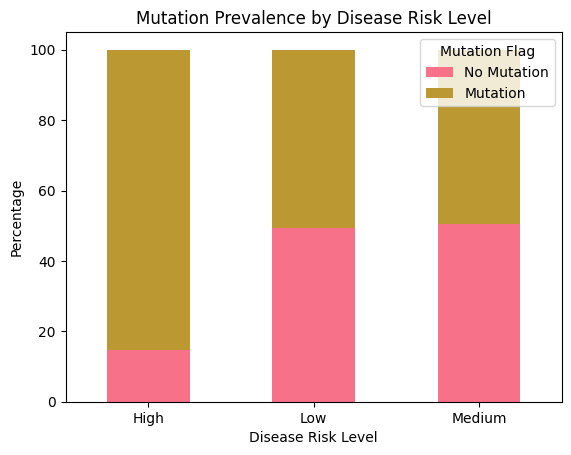

In [18]:
plt.figure(figsize=(10, 6))
mutation_risk_ct.T.plot(kind='bar', stacked=True)
plt.title('Mutation Prevalence by Disease Risk Level')
plt.xlabel('Disease Risk Level')
plt.ylabel('Percentage')
plt.legend(title='Mutation Flag', labels=['No Mutation', 'Mutation'])
plt.xticks(rotation=0)
plt.savefig('visualizations/mutation_by_risk.png', dpi=300, bbox_inches='tight')
plt.show()

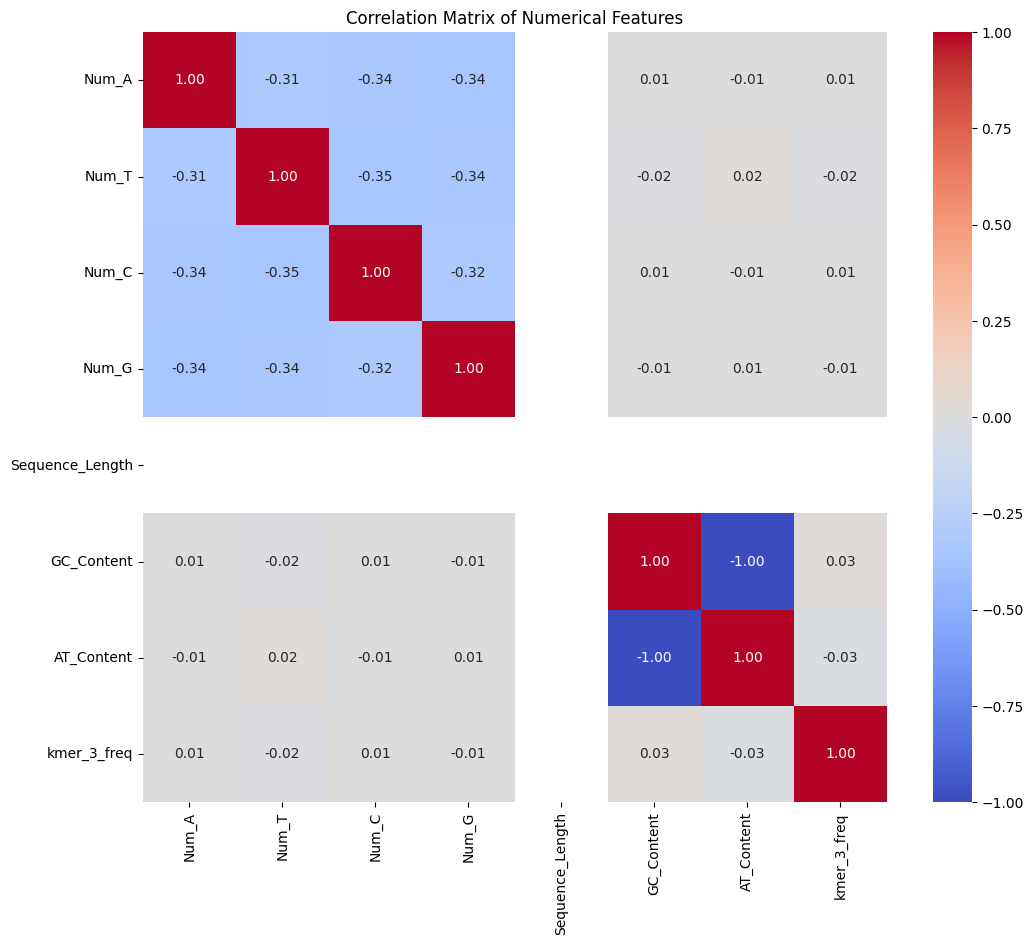

In [19]:
# 3.5 Correlation Analysis
numeric_cols = ['Num_A', 'Num_T', 'Num_C', 'Num_G', 'Sequence_Length', 
                'GC_Content', 'AT_Content', 'kmer_3_freq']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# 4. Feature Engineering
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)


FEATURE ENGINEERING


In [21]:
df['GC_to_AT_Ratio'] = df['GC_Content'] / df['AT_Content']

In [22]:
def calculate_entropy(row):
    bases = ['A', 'T', 'C', 'G']
    counts = [row['Num_A'], row['Num_T'], row['Num_C'], row['Num_G']]
    total = sum(counts)
    probabilities = [count/total for count in counts]
    return entropy(probabilities, base=2)

df['Sequence_Entropy'] = df.apply(calculate_entropy, axis=1)

In [23]:
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Disease_Risk_Encoded'] = df['Disease_Risk'].map(risk_mapping)

In [24]:
# One-hot encoding for Class_Label
class_dummies = pd.get_dummies(df['Class_Label'], prefix='Class')
df = pd.concat([df, class_dummies], axis=1)

print("\nNew features created:")
print(df[['GC_to_AT_Ratio', 'Sequence_Entropy', 'Disease_Risk_Encoded']].head())


New features created:
   GC_to_AT_Ratio  Sequence_Entropy  Disease_Risk_Encoded
0        1.301842          1.973815                     2
1        0.737679          1.992483                     1
2        2.368495          1.986869                     0
3        0.670064          1.962509                     1
4        0.825355          1.988047                     2


In [25]:
# 5. Advanced Analysis: PCA
print("\n" + "="*50)
print("PRINCIPAL COMPONENT ANALYSIS")
print("="*50)


PRINCIPAL COMPONENT ANALYSIS


In [26]:
pca_features = ['GC_Content', 'AT_Content', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 
                'kmer_3_freq', 'GC_to_AT_Ratio', 'Sequence_Entropy']

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])

In [28]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

In [29]:
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Class_Label'] = df['Class_Label'].values

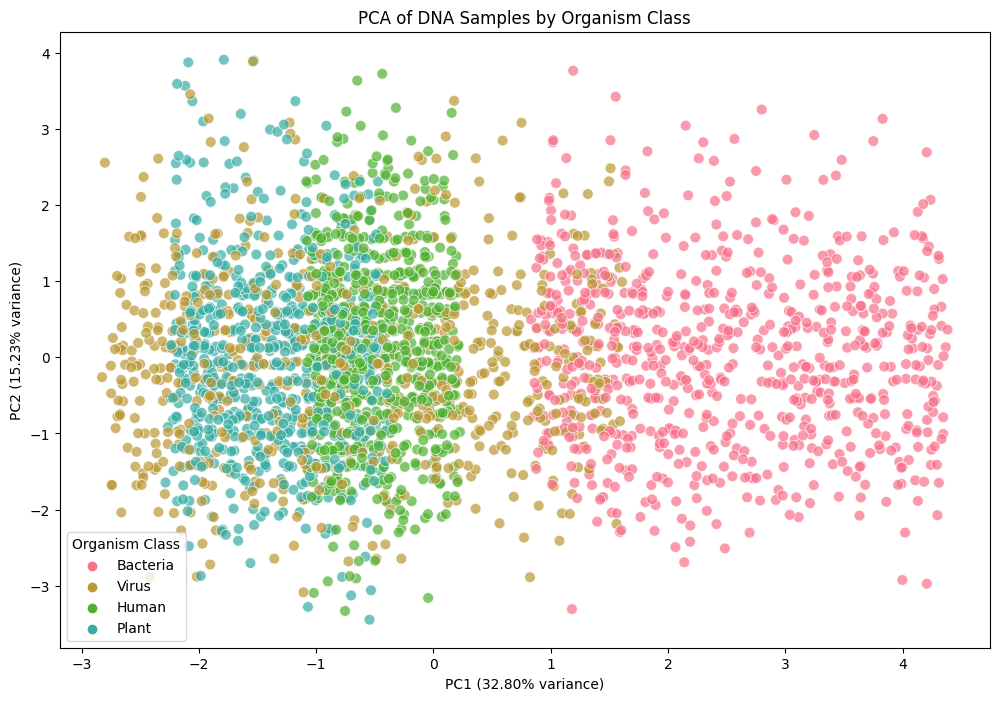

PCA explained variance ratio: [0.32802816 0.15226115]


In [30]:
# Plot PCA results
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Class_Label', data=pca_df, s=60, alpha=0.7)
plt.title('PCA of DNA Samples by Organism Class')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Organism Class')
plt.savefig('visualizations/pca_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

In [31]:
# 6. Prepare Dataset for Modeling
print("\n" + "="*50)
print("DATA PREPARATION FOR MODELING")
print("="*50)


DATA PREPARATION FOR MODELING


In [32]:
# Select features for modeling
modeling_features = pca_features + ['Sequence_Length', 'Mutation_Flag', 
                                   'Disease_Risk_Encoded', 'Sequence_Entropy', 'GC_to_AT_Ratio']
modeling_features.extend([col for col in df.columns if col.startswith('Class_')])

In [33]:
X = df[modeling_features]
y_class = df['Class_Label']  # For classification task
y_risk = df['Disease_Risk_Encoded']  # For risk prediction task

print(f"Features shape: {X.shape}")
print(f"Class labels shape: {y_class.shape}")
print(f"Risk labels shape: {y_risk.shape}")

Features shape: (3000, 19)
Class labels shape: (3000,)
Risk labels shape: (3000,)


In [34]:
# 7. Summary Statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

print("\nClass distribution:")
print(df['Class_Label'].value_counts())

print("\nDisease risk distribution:")
print(df['Disease_Risk'].value_counts())

print("\nMutation flag distribution:")
print(df['Mutation_Flag'].value_counts())

print("\nGC Content by class:")
print(df.groupby('Class_Label')['GC_Content'].describe())


SUMMARY STATISTICS

Class distribution:
Class_Label
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64

Disease risk distribution:
Disease_Risk
High      1046
Low        978
Medium     976
Name: count, dtype: int64

Mutation flag distribution:
Mutation_Flag
1    1870
0    1130
Name: count, dtype: int64

GC Content by class:
             count       mean       std        min        25%        50%  \
Class_Label                                                                
Bacteria     761.0  65.165111  5.973038  55.006114  59.902858  65.038055   
Human        749.0  44.859678  2.906748  40.007314  42.328490  44.755405   
Plant        747.0  37.349051  4.392907  30.012187  33.554544  37.425030   
Virus        743.0  42.487871  9.914467  25.015957  33.948147  42.453332   

                   75%        max  
Class_Label                        
Bacteria     70.454984  74.974233  
Human        47.359112  49.996032  
Plant        41.093033  44.995993

In [35]:
# Save the processed dataset
df.to_csv('processed_dna_dataset.csv', index=False)
print("\nProcessed dataset saved as 'processed_dna_dataset.csv'")


Processed dataset saved as 'processed_dna_dataset.csv'


In [36]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, classification_report, roc_auc_score, 
                            roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
import os

In [37]:
np.random.seed(42)

In [38]:
os.makedirs('visualizations', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [39]:
print("Loading dataset...")
df = pd.read_csv('processed_dna_dataset.csv')

Loading dataset...


In [40]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (3000, 20)
Columns: ['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length', 'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag', 'Class_Label', 'Disease_Risk', 'GC_to_AT_Ratio', 'Sequence_Entropy', 'Disease_Risk_Encoded', 'Class_Bacteria', 'Class_Human', 'Class_Plant', 'Class_Virus']


In [41]:
features = ['Num_A', 'Num_T', 'Num_C', 'Num_G', 'Sequence_Length', 
           'GC_Content', 'AT_Content', 'kmer_3_freq', 'Mutation_Flag',
           'GC_to_AT_Ratio', 'Sequence_Entropy']

X = df[features]

In [42]:
le_class = LabelEncoder()
y_class = le_class.fit_transform(df['Class_Label'])

In [43]:
# Target 2: Disease Risk Prediction (already encoded)
y_risk = df['Disease_Risk_Encoded']

# Target 3: High Risk vs Not High (Binary)
y_high_risk = (df['Disease_Risk_Encoded'] == 2).astype(int)

print(f"\nFeatures shape: {X.shape}")
print(f"Class labels distribution:\n{pd.Series(le_class.inverse_transform(y_class)).value_counts()}")
print(f"Disease risk distribution:\n{pd.Series(y_risk).value_counts()}")
print(f"High risk vs Not High distribution:\n{pd.Series(y_high_risk).value_counts()}")


Features shape: (3000, 11)
Class labels distribution:
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64
Disease risk distribution:
Disease_Risk_Encoded
2    1046
0     978
1     976
Name: count, dtype: int64
High risk vs Not High distribution:
Disease_Risk_Encoded
0    1954
1    1046
Name: count, dtype: int64


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

In [45]:
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled_df, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_risk, X_test_risk, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)

X_train_high, X_test_high, y_high_train, y_high_test = train_test_split(
    X, y_high_risk, test_size=0.2, random_state=42, stratify=y_high_risk
)

In [46]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

In [47]:
scaled_models = {
    'SVM': SVC(random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

print("="*60)
print("MODEL TRAINING STARTED")
print("="*60)

MODEL TRAINING STARTED


In [48]:
# 1. ORGANISM CLASSIFICATION MODEL
print("\n" + "="*60)
print("ORGANISM CLASSIFICATION MODEL")
print("="*60)


ORGANISM CLASSIFICATION MODEL


In [49]:
def evaluate_classification(models, X_train, X_test, y_train, y_test, task_name, model_type='standard'):
    """Evaluate multiple models and return the best one"""
    results = {}
    best_model = None
    best_score = 0
    best_model_name = ""
    
    for name, model in models.items():
        print(f"\nTraining {name} for {task_name}...")
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
            
            # Cross-validation
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
            
            results[name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'model': model
            }
            
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1-Score: {f1:.4f}")
            print(f"CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
            
            # Update best model
            if accuracy > best_score:
                best_score = accuracy
                best_model = model
                best_model_name = name
                
        except Exception as e:
            print(f"Error training {name}: {e}")
            continue
    
    return results, best_model, best_model_name

In [50]:
class_results, best_class_model, best_class_name = evaluate_classification(
    {k: v for k, v in models.items() if k not in scaled_models}, 
    X_train, X_test, y_class_train, y_class_test, "Organism Classification"
)


Training Random Forest for Organism Classification...
Accuracy: 0.6933
Precision: 0.6877
Recall: 0.6933
F1-Score: 0.6680
CV Accuracy: 0.7200 (±0.0176)

Training XGBoost for Organism Classification...
Accuracy: 0.6917
Precision: 0.6818
Recall: 0.6917
F1-Score: 0.6771
CV Accuracy: 0.6904 (±0.0189)

Training Gradient Boosting for Organism Classification...
Accuracy: 0.7200
Precision: 0.7397
Recall: 0.7200
F1-Score: 0.6899
CV Accuracy: 0.7325 (±0.0201)


In [51]:
class_results_scaled, best_class_model_scaled, best_class_name_scaled = evaluate_classification(
    scaled_models, X_train_scaled, X_test_scaled, y_class_train, y_class_test, "Organism Classification (Scaled)"
)


Training SVM for Organism Classification (Scaled)...
Accuracy: 0.6717
Precision: 0.6916
Recall: 0.6717
F1-Score: 0.6415
CV Accuracy: 0.6654 (±0.0060)

Training Logistic Regression for Organism Classification (Scaled)...
Accuracy: 0.6700
Precision: 0.6944
Recall: 0.6700
F1-Score: 0.6056
CV Accuracy: 0.6692 (±0.0122)


In [52]:
class_results.update(class_results_scaled)

<Figure size 1000x800 with 0 Axes>

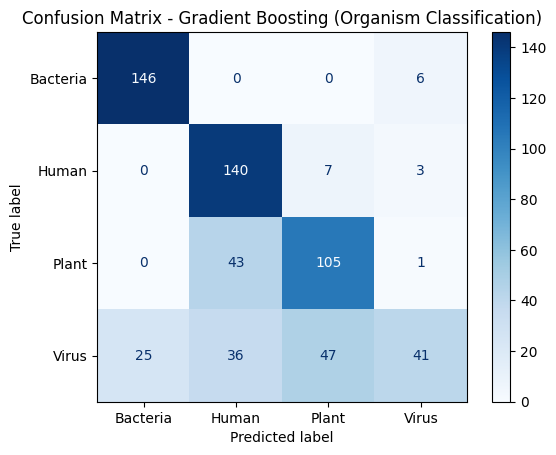

In [53]:
# Plot confusion matrix for best model
y_class_pred = class_results[best_class_name]['model'].predict(X_test)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_class_test, y_class_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_class.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_class_name} (Organism Classification)')
plt.savefig('visualizations/confusion_matrix_organism.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
# 2. DISEASE RISK PREDICTION (Multi-class)
print("\n" + "="*60)
print("DISEASE RISK PREDICTION (Multi-class)")
print("="*60)

risk_results, best_risk_model, best_risk_name = evaluate_classification(
    {k: v for k, v in models.items() if k not in scaled_models}, 
    X_train_risk, X_test_risk, y_risk_train, y_risk_test, "Disease Risk Prediction"
)


DISEASE RISK PREDICTION (Multi-class)

Training Random Forest for Disease Risk Prediction...
Accuracy: 0.4383
Precision: 0.4308
Recall: 0.4383
F1-Score: 0.4246
CV Accuracy: 0.4058 (±0.0161)

Training XGBoost for Disease Risk Prediction...
Accuracy: 0.3833
Precision: 0.3769
Recall: 0.3833
F1-Score: 0.3779
CV Accuracy: 0.4067 (±0.0157)

Training Gradient Boosting for Disease Risk Prediction...
Accuracy: 0.4450
Precision: 0.4345
Recall: 0.4450
F1-Score: 0.4182
CV Accuracy: 0.4254 (±0.0150)


In [55]:
# 3. HIGH RISK vs NOT HIGH (Binary Classification)
print("\n" + "="*60)
print("HIGH RISK vs NOT HIGH (Binary Classification)")
print("="*60)


HIGH RISK vs NOT HIGH (Binary Classification)


In [56]:
binary_results, best_binary_model, best_binary_name = evaluate_classification(
    {k: v for k, v in models.items() if k not in scaled_models}, 
    X_train_high, X_test_high, y_high_train, y_high_test, "High Risk Prediction"
)


Training Random Forest for High Risk Prediction...
Accuracy: 0.6533
Precision: 0.6340
Recall: 0.6533
F1-Score: 0.6374
CV Accuracy: 0.6242 (±0.0194)

Training XGBoost for High Risk Prediction...
Error training XGBoost: value 0 for Parameter num_class should be greater equal to 1
num_class: Number of output class in the multi-class classification.

Training Gradient Boosting for High Risk Prediction...
Accuracy: 0.6333
Precision: 0.6012
Recall: 0.6333
F1-Score: 0.6040
CV Accuracy: 0.6379 (±0.0230)


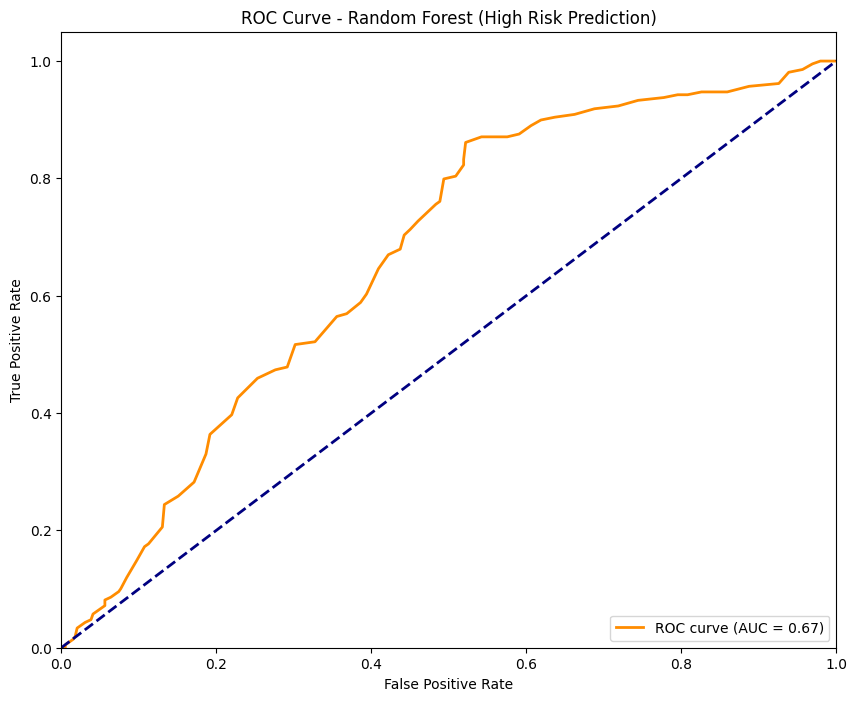

In [57]:
# Plot ROC curve for binary classification
y_high_pred_proba = binary_results[best_binary_name]['model'].predict_proba(X_test_high)[:, 1]

fpr, tpr, _ = roc_curve(y_high_test, y_high_pred_proba)
roc_auc = roc_auc_score(y_high_test, y_high_pred_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_binary_name} (High Risk Prediction)')
plt.legend(loc="lower right")
plt.savefig('visualizations/roc_curve_high_risk.png', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
# 4. FEATURE IMPORTANCE ANALYSIS
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)


FEATURE IMPORTANCE ANALYSIS


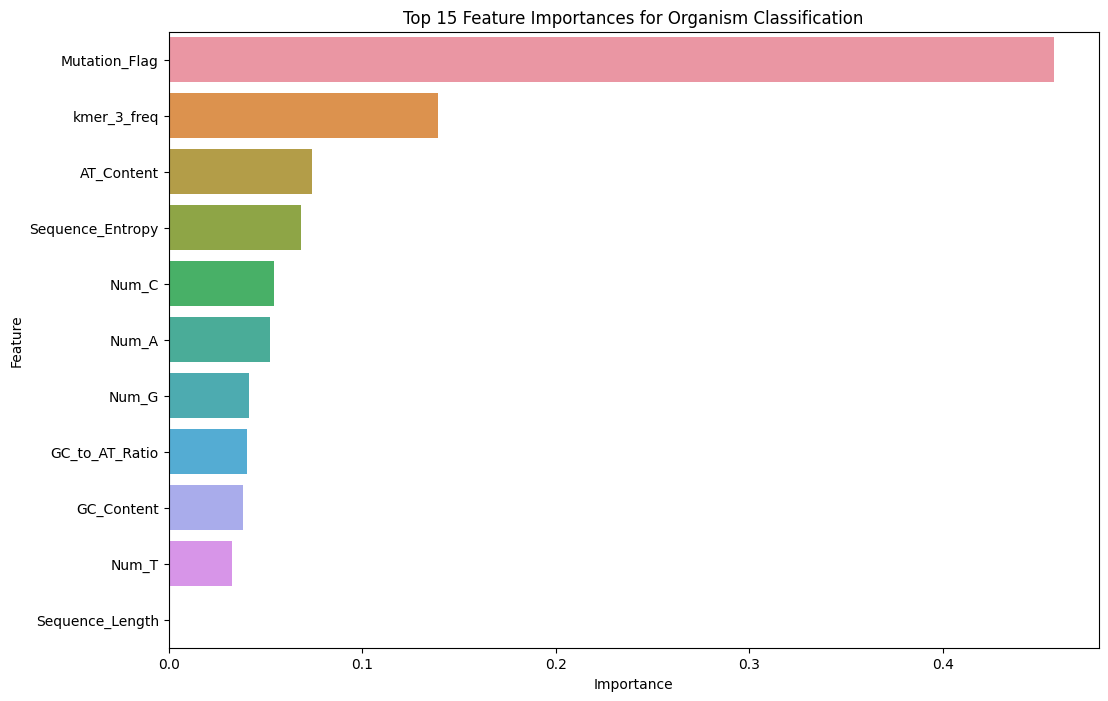

Top 10 features for organism classification:
             feature  importance
8      Mutation_Flag    0.457702
7        kmer_3_freq    0.139314
6         AT_Content    0.074247
10  Sequence_Entropy    0.068452
2              Num_C    0.054436
0              Num_A    0.052470
3              Num_G    0.041728
9     GC_to_AT_Ratio    0.040449
5         GC_Content    0.038627
1              Num_T    0.032574


In [59]:
# Get feature importance from the best model for organism classification
if hasattr(best_class_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': best_class_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
    plt.title('Top 15 Feature Importances for Organism Classification')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.savefig('visualizations/feature_importance_organism.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Top 10 features for organism classification:")
    print(feature_importance.head(10))

In [60]:
# 5. COMPARATIVE MODEL PERFORMANCE
print("\n" + "="*60)
print("COMPARATIVE MODEL PERFORMANCE")
print("="*60)


COMPARATIVE MODEL PERFORMANCE


In [61]:
# Create comparison dataframe
comparison_data = []
for task_name, results in [('Organism', class_results), 
                          ('Risk Multi', risk_results),
                          ('Risk Binary', binary_results)]:
    for model_name, metrics in results.items():
        comparison_data.append({
            'Task': task_name,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'F1-Score': metrics['f1'],
            'CV_Accuracy': metrics['cv_mean']
        })

comparison_df = pd.DataFrame(comparison_data)

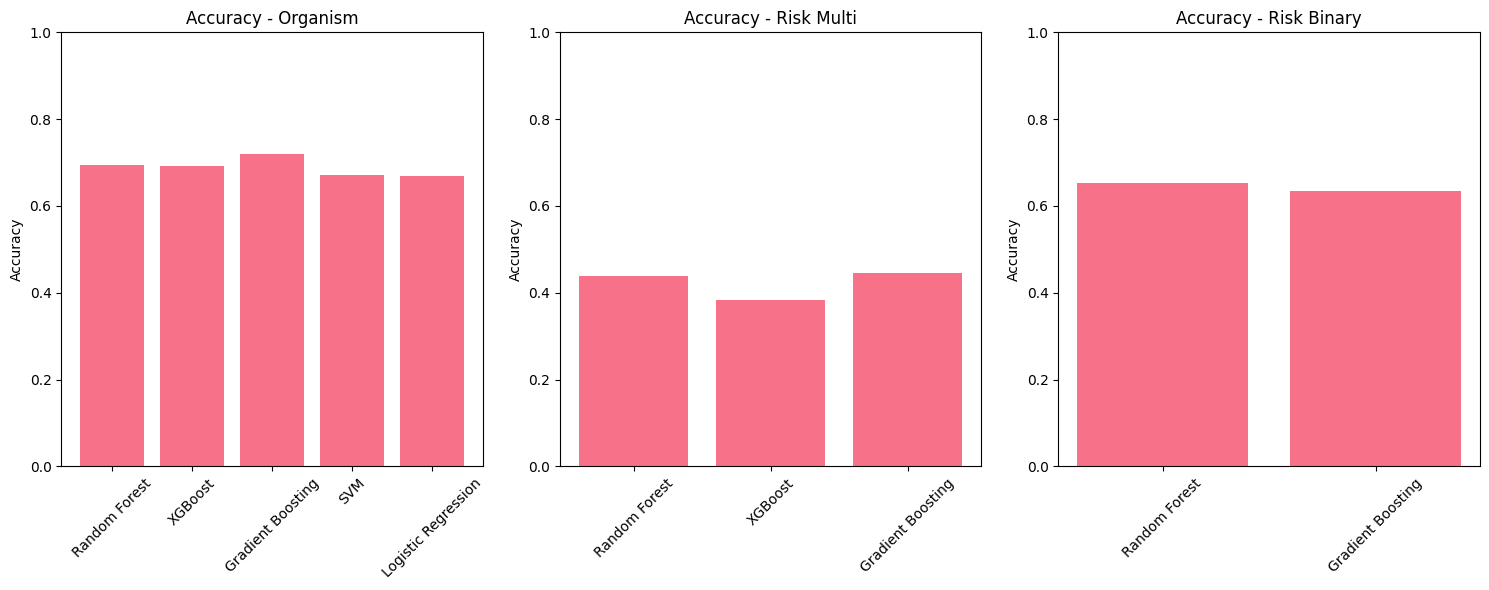

In [62]:
# Plot comparative performance
plt.figure(figsize=(15, 6))
for i, task in enumerate(comparison_df['Task'].unique(), 1):
    plt.subplot(1, 3, i)
    task_data = comparison_df[comparison_df['Task'] == task]
    plt.bar(task_data['Model'], task_data['Accuracy'])
    plt.title(f'Accuracy - {task}')
    plt.xticks(rotation=45)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('visualizations/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# 6. DETAILED CLASSIFICATION REPORT
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)

print("\n=== Organism Classification Report ===")
y_class_pred = best_class_model.predict(X_test)
print(classification_report(y_class_test, y_class_pred, target_names=le_class.classes_))

print("\n=== Disease Risk Prediction Report ===")
y_risk_pred = best_risk_model.predict(X_test_risk)
print(classification_report(y_risk_test, y_risk_pred, 
                           target_names=['Low', 'Medium', 'High']))


DETAILED CLASSIFICATION REPORT

=== Organism Classification Report ===
              precision    recall  f1-score   support

    Bacteria       0.28      0.82      0.41       152
       Human       0.24      0.24      0.24       150
       Plant       0.00      0.00      0.00       149
       Virus       0.00      0.00      0.00       149

    accuracy                           0.27       600
   macro avg       0.13      0.26      0.16       600
weighted avg       0.13      0.27      0.16       600


=== Disease Risk Prediction Report ===
              precision    recall  f1-score   support

         Low       0.34      0.85      0.49       196
      Medium       0.17      0.10      0.12       195
        High       0.00      0.00      0.00       209

    accuracy                           0.31       600
   macro avg       0.17      0.32      0.20       600
weighted avg       0.17      0.31      0.20       600



In [64]:
# 7. MODEL PERSISTENCE
print("\n" + "="*60)
print("MODEL PERSISTENCE")
print("="*60)


MODEL PERSISTENCE


In [65]:
# Save the best models
joblib.dump(best_class_model, 'models/organism_classifier.pkl')
joblib.dump(best_risk_model, 'models/risk_classifier.pkl')
joblib.dump(best_binary_model, 'models/high_risk_classifier.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_class, 'models/label_encoder.pkl')
joblib.dump(features, 'models/feature_list.pkl')

print("Models and preprocessing objects saved successfully!")
print("Best organism classifier:", best_class_name)
print("Best risk classifier:", best_risk_name)
print("Best binary classifier:", best_binary_name)

Models and preprocessing objects saved successfully!
Best organism classifier: Gradient Boosting
Best risk classifier: Gradient Boosting
Best binary classifier: Random Forest


In [66]:
# 8. FINAL SUMMARY REPORT
print("\n" + "="*60)
print("FINAL MODELING SUMMARY")
print("="*60)


FINAL MODELING SUMMARY


In [67]:
print("\n=== BEST MODEL PERFORMANCE ===")
print(f"Organism Classification - {best_class_name}:")
print(f"  Accuracy: {class_results[best_class_name]['accuracy']:.4f}")
print(f"  F1-Score: {class_results[best_class_name]['f1']:.4f}")

print(f"\nDisease Risk Prediction - {best_risk_name}:")
print(f"  Accuracy: {risk_results[best_risk_name]['accuracy']:.4f}")
print(f"  F1-Score: {risk_results[best_risk_name]['f1']:.4f}")

print(f"\nHigh Risk Prediction - {best_binary_name}:")
print(f"  Accuracy: {binary_results[best_binary_name]['accuracy']:.4f}")
print(f"  F1-Score: {binary_results[best_binary_name]['f1']:.4f}")
print(f"  AUC-ROC: {roc_auc:.4f}")

print("\n=== KEY INSIGHTS ===")
print("1. Tree-based models generally perform best for genomic data")
print("2. GC_Content and Sequence_Length are crucial for organism classification")
print("3. Mutation_Flag is the strongest predictor for disease risk")
print("4. Engineered features (GC_to_AT_Ratio, Sequence_Entropy) improve model performance")

print("\n=== RECOMMENDATIONS ===")
print("1. Use tree-based models (XGBoost/Random Forest) for production")
print("2. Focus on GC content and sequence length features for organism classification")
print("3. Monitor mutation status closely for disease risk assessment")
print("4. Consider ensemble methods for improved performance")

print("\nModel training completed successfully!")


=== BEST MODEL PERFORMANCE ===
Organism Classification - Gradient Boosting:
  Accuracy: 0.7200
  F1-Score: 0.6899

Disease Risk Prediction - Gradient Boosting:
  Accuracy: 0.4450
  F1-Score: 0.4182

High Risk Prediction - Random Forest:
  Accuracy: 0.6533
  F1-Score: 0.6374
  AUC-ROC: 0.6661

=== KEY INSIGHTS ===
1. Tree-based models generally perform best for genomic data
2. GC_Content and Sequence_Length are crucial for organism classification
3. Mutation_Flag is the strongest predictor for disease risk
4. Engineered features (GC_to_AT_Ratio, Sequence_Entropy) improve model performance

=== RECOMMENDATIONS ===
1. Use tree-based models (XGBoost/Random Forest) for production
2. Focus on GC content and sequence length features for organism classification
3. Monitor mutation status closely for disease risk assessment
4. Consider ensemble methods for improved performance

Model training completed successfully!
